
<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

# Outliers

## Eduardo Pécora, Ph.D.

## Pipeline para detecção de outliers

### Objetivos:

* Introduzir o conceito de outliers
* Aprender a usar o algoritmos de machine learning para detecção de outliers

### Pipeline para detecção de outliers

#### Etapas:
1. Visualizar distribuição
2. Testar normalidade
3. Calcular assimetria

Dependendo das respostas em 1. e 2.

* Aplicar métodos clássicos
* Aplicar Machine Learning

Analisar Resulatdos

In [183]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from scipy.stats import zscore
from scipy.stats import skew

from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# GERANDO DADOS COM OUTLIERS (vc pode substituir essa parte com os seus dados)

# Dados normais (1000 observações com média = 50 e desvio-padrão = 5)
dados_normais = np.random.normal(loc=50, scale=5, size=1000)

# Inserindo alguns outliers artificiais
dados_normais = np.append(dados_normais, [35, 30, 32, 28, 75, 90, 95, 100])

# Embaralhar os dados normais para espalhar os outliers
np.random.shuffle(dados_normais)

# Dados exponenciais (assimétricos) (1000 observações com lambda = 1/10)
dados_exp = np.random.exponential(scale=10, size=1000)

# Inserindo valores extremos
dados_exp = np.append(dados_exp, [80, 82, 95, 100, 120])

# Embaralhar os dados exponenciais para espalhar os outliers
np.random.shuffle(dados_exp)

df_normal = pd.DataFrame({
    'valor': dados_normais
})

df_exp = pd.DataFrame({
    'valor': dados_exp
})

# ==========================================================
# FUNÇÃO DE VISUALIZAÇÃO
# ==========================================================

def visualizar_distribuicao(df):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # HISTOGRAMA + KDE
    sns.histplot( data=df, x='valor', bins=30,
        kde=True, line_kws={'linewidth':3}, ax=ax[0])

    ax[0].set_title(f'Histograma + KDE')
    ax[0].set_xlabel('Valor')
    ax[0].set_ylabel('Frequência')

    # BOXPLOT

    sns.boxplot( x=df['valor'], ax=ax[1])

    ax[1].set_title(f'Boxplot')
    ax[1].set_xlabel('Valor')

    plt.tight_layout()
    plt.show()

In [184]:
# Uma distribuição por vez

df = df_normal
#df = df_exp

## Análises Iniciais

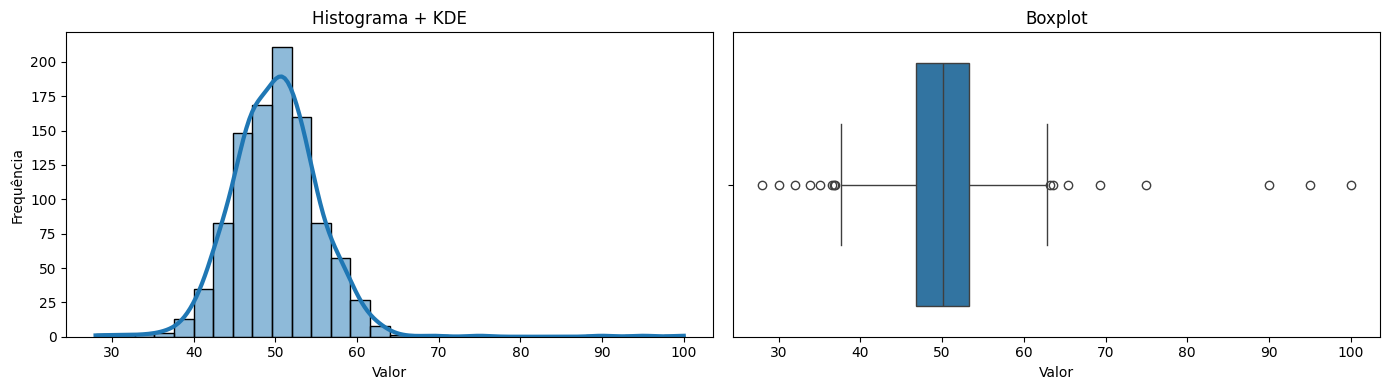

In [185]:
# VISUALIZAÇÃO INICIAL

visualizar_distribuicao(df)

In [186]:
# TESTE DE NORMALIDADE

def testar_normalidade(df):
    estatistica, pvalor = shapiro(df['valor'])
    print(f'TESTE DE NORMALIDADE')

    print(f'Estatística: {estatistica:.4f}')
    print(f'P-valor: {pvalor:.4f}')

    if pvalor > 0.05:
        print('Distribuição aproximadamente NORMAL')
    else:
        print('Distribuição NÃO normal')
    print()

# EXECUTANDO TESTES

testar_normalidade(df)


TESTE DE NORMALIDADE
Estatística: 0.9139
P-valor: 0.0000
Distribuição NÃO normal



In [187]:
# ASSIMETRIA

def calcular_assimetria(df):
    valor_skew = skew(df['valor'])

    print(f'ASSIMETRIA')
    print(f'Skewness: {valor_skew:.4f}')

    if abs(valor_skew) < 0.5:
        print('Distribuição aproximadamente simétrica')
    elif abs(valor_skew) < 1:
        print('Assimetria moderada')
    else:
        print('Assimetria forte')

# EXECUTANDO ASSIMETRIA

calcular_assimetria(df)


ASSIMETRIA
Skewness: 1.4964
Assimetria forte


# Função para visualização gráfica

In [188]:
# VISUALIZAÇÃO OUTLIERS

def plot_outliers(df, coluna_outlier, titulo):
    plt.figure(figsize=(12,4))

    cores = df[coluna_outlier].map({
        False: 'steelblue',
        True: 'red'})

    cores_unimed = df[coluna_outlier].map({
        False: '#00995D',   # Verde
        True: '#FF8C00'     # Laranja
        })

    plt.scatter(
        range(len(df)),
        df['valor'],
        c=cores,
        alpha=0.9)

    plt.title(titulo)
    plt.xlabel('Índice')
    plt.ylabel('Valor')
    plt.show()

## Z-SCORE

OUTLIERS PELO Z-SCORE
Outliers: 8



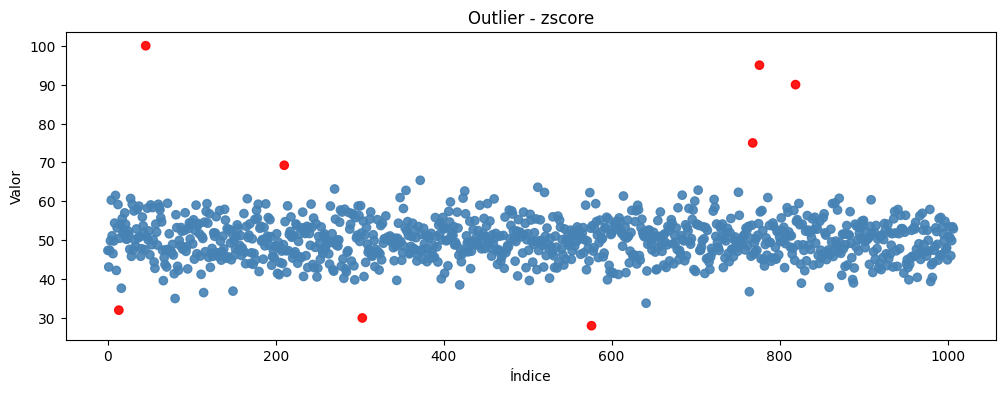

In [189]:
# MÉTODO Z-SCORE
# threshold=3 (três desvios-padrão)
def detectar_zscore(df, threshold=3):

    df = df.copy()
    df['zscore'] = zscore(df['valor'])
    df['outlier_zscore'] = abs(df['zscore']) > threshold

    return df

# APLICANDO Z-SCORE

df_z = detectar_zscore(df)

# CONTAGEM DE OUTLIERS

print('OUTLIERS PELO Z-SCORE')

print(f'Outliers: {df_z["outlier_zscore"].sum()}')
print()

plot_outliers( df_z, 'outlier_zscore', 'Outlier - zscore', )

# InterQuartile Range (IQR)

OUTLIERS PELO IQR
Outliers: 16



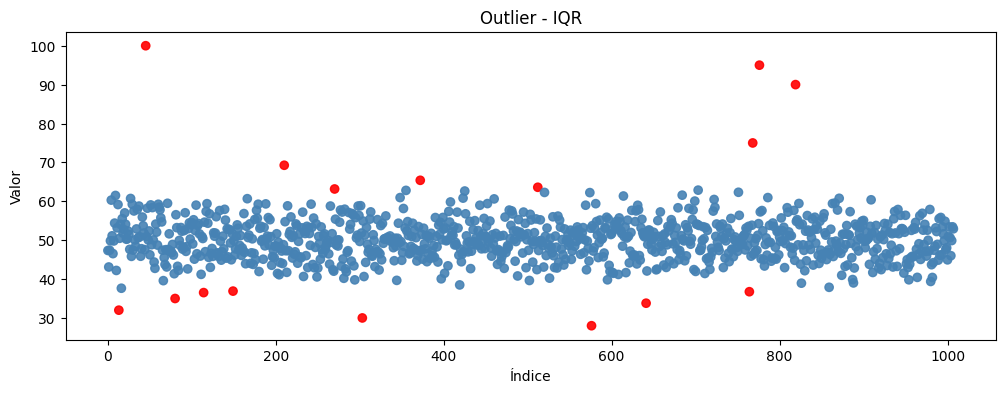

In [190]:
# IQR (BOXPLOT)

def detectar_iqr(df):
    df = df.copy()
    Q1 = df['valor'].quantile(0.25)
    Q3 = df['valor'].quantile(0.75)

    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df['outlier_iqr'] = ((df['valor'] < limite_inferior) |
        (df['valor'] > limite_superior))
    return df

# APLICANDO IQR
df_iqr = detectar_iqr(df)

# CONTAGEM IQR

print('OUTLIERS PELO IQR')
print(f'Outliers: {df_iqr["outlier_iqr"].sum()}')
print()
plot_outliers( df_iqr, 'outlier_iqr', 'Outlier - IQR', )


## ISOLATION FOREST

OUTLIERS PELO ISOLATION FOREST
Outliers: 11



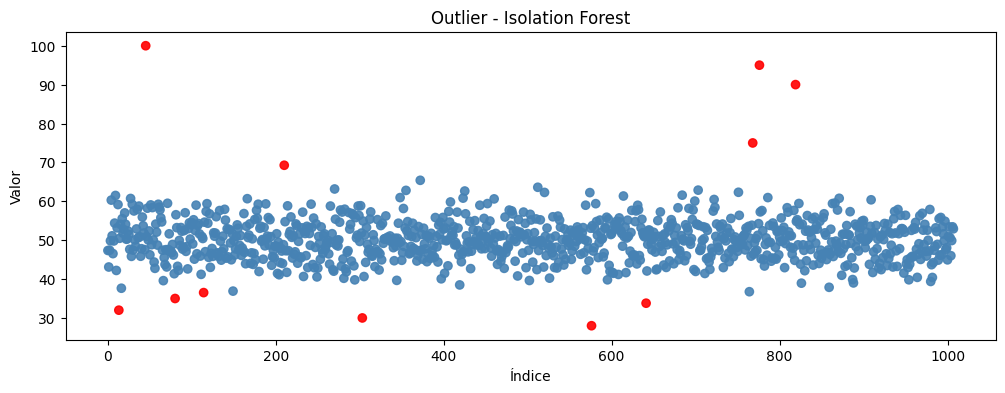

In [191]:
# ISOLATION FOREST

def aplicar_isolation_forest(df, contamination):
    modelo = IsolationForest( contamination= contamination, random_state=42)

    df = df.copy()
    df['iforest'] = modelo.fit_predict(df[['valor']])
    df['outlier_iforest'] = df['iforest'] == -1
    return df

# EXECUTANDO ISOLATION FOREST

df_iforest = aplicar_isolation_forest(df, 0.01)

# CONTAGEM ISOLATION FOREST
print('OUTLIERS PELO ISOLATION FOREST')
print(f'Outliers: {df_iforest["outlier_iforest"].sum()}')
print()
plot_outliers( df_iforest, 'outlier_iforest', 'Outlier - Isolation Forest', )

## DBSCAN

OUTLIERS PELO DBSCAN
Outliers: 8



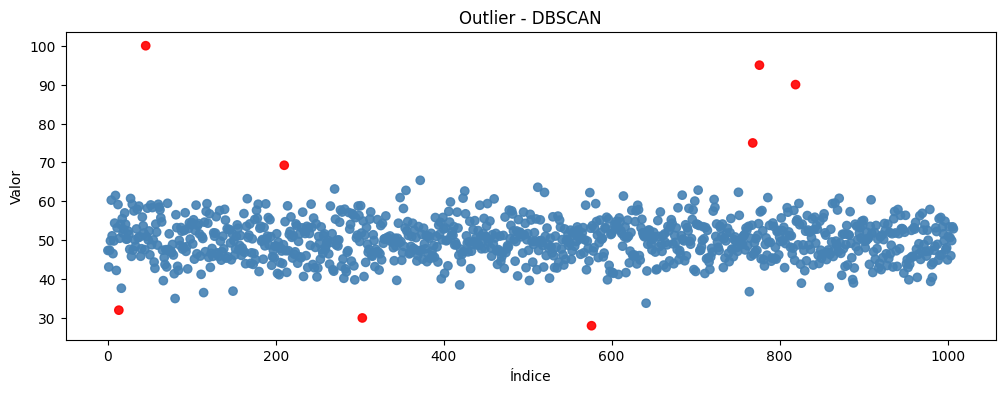

In [192]:
# DBSCAN PARA DETECÇÃO DE OUTLIERS

def aplicar_dbscan(df, eps=0.5, min_samples=5):
    df = df.copy()

    # PADRONIZAÇÃO
    scaler = StandardScaler()
    X = scaler.fit_transform(df[['valor']])

    # MODELO DBSCAN
    modelo = DBSCAN( eps=eps, min_samples=min_samples)

    # FIT
    clusters = modelo.fit_predict(X)
    df['cluster'] = clusters

    # No DBSCAN:
    # cluster = -1 significa OUTLIER

    df['outlier_dbscan'] = df['cluster'] == -1
    return df

# EXECUTANDO DB_SCAN

df_dbscan = aplicar_dbscan(df)

# CONTAGEM DBSCAN
print('OUTLIERS PELO DBSCAN')
print(f'Outliers: {df_dbscan["outlier_dbscan"].sum()}')
print()
plot_outliers( df_dbscan, 'outlier_dbscan', 'Outlier - DBSCAN', )

## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!
  

## <h3 align="center"> (c) Liga Data Science/ UFPR 2026. All rights reserved. <h3/>

## Autor

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 18-05-2025       | 1.0     | Eduardo Pecora    | Inicial               ||

<hr>